In [1]:
# [步驟一] 環境建置與套件匯入
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import requests
from bs4 import BeautifulSoup
import jieba
from collections import Counter
import time
import random

# 判斷是否為 Linux 環境 (Colab)，若是則自動安裝開源中文字型，以解決圖表亂碼問題。
if os.name == 'posix':
    if not os.path.exists('/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'):
        print("正在安裝圖表專用中文字型... (約需 10 秒)")
        os.system('apt-get update -qq > /dev/null')
        os.system('apt-get install -y fonts-wqy-zenhei -qq > /dev/null')

    # 強制將 Matplotlib 的字型設定為「文泉驛正黑體」。
    font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='WenQuanYi Zen Hei')
else:
    # Windows 環境下的備用設定。
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
    plt.rcParams['axes.unicode_minus'] = False

print("環境建置完成！")

環境建置完成！


In [2]:
# [步驟二] 定義資料爬取與文字處理函式 (標準潔淨版)

def get_ptt_articles(url, max_posts=10):
    articles = []
    # 偽裝成一般瀏覽器
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0 Safari/537.36',
        'Referer': 'https://www.ptt.cc/bbs/Gossiping/index.html'
    }

    try:
        print(f"正在連線至 {url} ...")
        # 發送請求，設定 10 秒超時，避免卡太久
        response = requests.get(url, cookies={'over18': '1'}, headers=headers, timeout=10)

        soup = BeautifulSoup(response.text, 'html.parser')
        titles = soup.select('div.title a')

        print(f"連線成功！找到 {len(titles)} 篇文章，準備進行爬取...")

        for i, title in enumerate(titles):
            if i >= max_posts: break

            # 隨機休息 1~2 秒，避免被判定為攻擊
            time.sleep(random.uniform(1, 2))

            article_url = "https://www.ptt.cc" + title['href']
            try:
                res = requests.get(article_url, cookies={'over18': '1'}, headers=headers, timeout=10)
                # 抓取並清洗內文
                content = BeautifulSoup(res.text, 'html.parser').select_one('#main-content')
                if content:
                    # 去除結尾簽名檔
                    text = content.text.split('--')[0]
                    articles.append(text)
                    print(f"  - 成功爬取第 {i+1} 篇: {title.text.strip()}")
            except Exception as e:
                print(f"  - 單篇爬取失敗: {e}")
                continue

    except Exception as e:
        print(f"主列表連線失敗: {e}")
        print("💡 建議：請重新執行此區塊 (Google Colab 連線有時不穩)")

    return articles

def text_to_words(texts):
    words = []
    # 設定停用詞 (包含網址與常見虛詞)
    stop_words = ['的', '了', '是', '我', '你', '在', '都', '看板', '作者', '標題', '時間',
                  'https', 'imgur', 'jpg', 'com', 'tw', 'www', 'href', '問卦', '新聞', '爆卦']

    for text in texts:
        # 分詞並過濾
        for word in jieba.cut(text):
            if len(word) > 1 and not word.isdigit() and word.lower() not in stop_words:
                words.append(word)
    return words

開始爬取 PTT 八卦版資料...
正在連線至 https://www.ptt.cc/bbs/Gossiping/index.html ...
連線成功！找到 9 篇文章，準備進行爬取...
  - 成功爬取第 1 篇: [問卦] 以前蓋房子有把廢棄物、土算進成本嗎？
  - 成功爬取第 2 篇: Re: [問卦] 社會秩序維護法 社維法是惡法嗎
  - 成功爬取第 3 篇: [新聞] 台南驚見「iPhone手槍」可殺人　45歲前
  - 成功爬取第 4 篇: [新聞] 快訊／宣布北市營養午餐將全面免費　蔣萬
  - 成功爬取第 5 篇: Re: [新聞] 外送員保障法三讀！每單報酬「不得低於45
  - 成功爬取第 6 篇: [新聞] 清晨引擎聲吵醒整條街！台中飆車族「炫耀
  - 成功爬取第 7 篇: [公告] 八卦板板規(2025.01.21)
  - 成功爬取第 8 篇: [公告] 【八卦美學獎】梗圖吐槽，共鳴豹紋笑翻！


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache


  - 成功爬取第 9 篇: [公告] 2025十大娛樂新聞 11/23~12/23推文投票
爬取完成，共取得 9 篇文章。


Loading model cost 1.068 seconds.
DEBUG:jieba:Loading model cost 1.068 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


熱門關鍵字: [('文章', 74), ('水桶', 52), ('八卦', 48), ('內容', 38), ('政治', 28), ('刪除', 25), ('張貼', 21), ('相關', 20), ('一個', 16), ('不得', 16)]


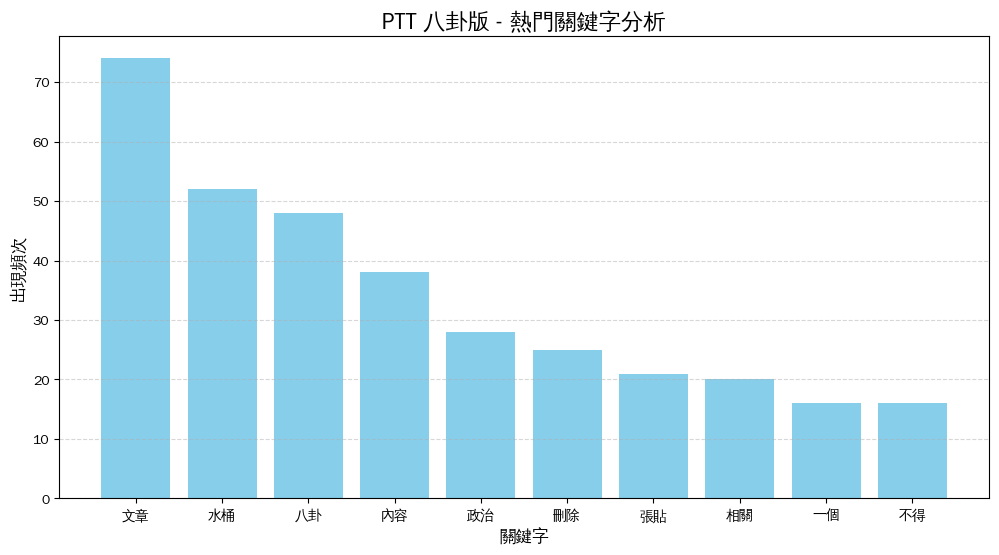

In [3]:
# [步驟三] 執行主程式與資料視覺化

print("開始爬取 PTT 八卦版資料...")
ptt_url = "https://www.ptt.cc/bbs/Gossiping/index.html"

# 執行爬蟲函式 (抓取最新的 10 篇文章)
articles = get_ptt_articles(ptt_url, max_posts=10)
print(f"爬取完成，共取得 {len(articles)} 篇文章。")

if articles:
    # 執行分詞與頻次統計
    top_words = Counter(text_to_words(articles)).most_common(10)
    print("熱門關鍵字:", top_words)

    # 繪製長條圖
    if top_words:
        labels, values = zip(*top_words)
        plt.figure(figsize=(12, 6))
        plt.bar(labels, values, color='skyblue')
        plt.title('PTT 八卦版 - 熱門關鍵字分析', fontsize=16)
        plt.xlabel('關鍵字', fontsize=12)
        plt.ylabel('出現頻次', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()